<a href="https://colab.research.google.com/github/KeyzaNadineKusumaRamadani/tugasKKA/blob/main/Tugas%20Analisis%20data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"keyzaramadani","key":"c60de2a34400b33936e274aa93126543"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [ ]:
!chmood 600 ~/.kaggle/kaggle.json

/bin/bash: line 1: chmood: command not found


In [ ]:
!kaggle datasets list -s "ecommerce data"

ref                                                             title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
cclark/product-item-data                                        eCommerce Item Data                                    140589  2016-08-18 00:32:54.173000          18286        212  0.7058824        
mmohaiminulislam/ecommerce-data-analysis                        ECommerce Data Analysis                              17628279  2024-01-01 02:04:35.787000           9918         69  1                
mkechinov/ecommerce-behavior-data-from-multi-category-store     eCommerce behavior data from multi category store  4606720907  2019-12-09 20:43:39.273000          76369        852  1                
jocke

In [ ]:
!kaggle datasets download -d carrie1/ecommerce-data

Dataset URL: https://www.kaggle.com/datasets/carrie1/ecommerce-data
License(s): unknown
100% 7.20M/7.20M [00:00<00:00, 120MB/s]



In [ ]:
!unzip ecommerce-data.zip

Archive:  ecommerce-data.zip
  inflating: data.csv                


In [ ]:
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/data.csv', encoding='ISO-8859-1')

In [ ]:
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


In [ ]:
print (df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['month'] = df['InvoiceDate'].dt.to_period('M').astype(str)
df['total_sales'] = df['Quantity'] * df['UnitPrice']
monthly_sales = df.groupby('month')['total_sales'].sum()
print(monthly_sales)


month
2010-12     748957.020
2011-01     560000.260
2011-02     498062.650
2011-03     683267.080
2011-04     493207.121
2011-05     723333.510
2011-06     691123.120
2011-07     681300.111
2011-08     682680.510
2011-09    1019687.622
2011-10    1070704.670
2011-11    1461756.250
2011-12     433668.010
Name: total_sales, dtype: float64


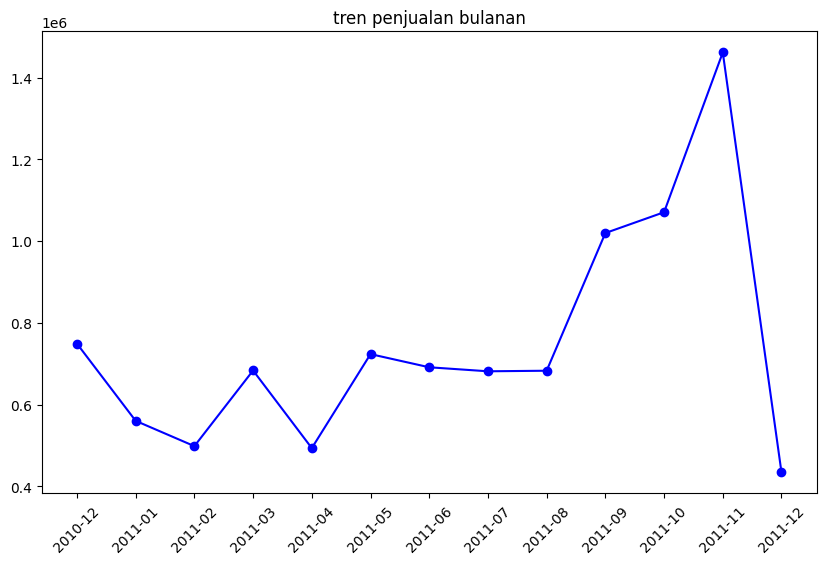

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='b')
plt.title('tren penjualan bulanan')
plt.xticks(rotation=45)
plt.show()

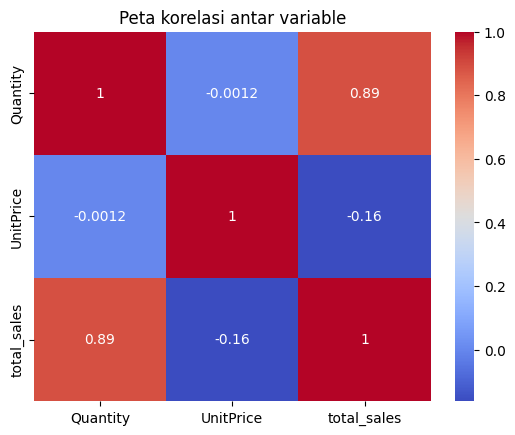

In [ ]:
correlation = df[['Quantity', 'UnitPrice', 'total_sales']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Peta korelasi antar variable')
plt.show()

In [ ]:
import datetime as dt
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

In [ ]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'total_sales' : sum })

/tmp/ipykernel_1679/4201789777.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  rfm = df.groupby('CustomerID').agg({


In [ ]:
rfm.columns = ['recency', 'frequency', 'monetary']

In [ ]:
rfm['R_Score'] = pd.qcut(rfm['recency'], 5, labels=[5, 4, 3, 2, 1]) # Recency kecil = Skor besar
rfm['F_Score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['monetary'], 5, labels=[1, 2, 3, 4, 5])

In [ ]:
rfm['RFM_Group'] = rfm.R_Score.astype(str) + rfm.F_Score.astype(str) + rfm.M_Score.astype(str)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['Quantity']] # Example Feature, 'Ad_Budget' was not found
y = df['total_sales'] # Target (corrected capitalization)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
print(f"Koefisien Iklan: {model.coef_[0]}")
print(f"Akurasi Model (R2 Score): {model.score(X_test, y_test)}")


Koefisien Iklan: 1.5086875277951282
Akurasi Model (R2 Score): 0.8633632506379764
